# The Limit of a Function

*Following Stewart, J., Clegg, D., & Watson, S. (2021). Calculus (9th ed.). Cengage Learning, Section 1.3.*

## Index
1. [The Door Analogy](#1)
2. [Diagram: Watching the Approach](#2)
3. [Example: Approaching x = 2](#3)
4. [Plain English](#4)
5. [Technical Definitions](#5)
6. [Computing Limits Numerically](#6)
7. [Exact Limits with SymPy](#7)
8. [References](#8)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Layout

import sympy
from sympy import symbols
from sympy.solvers import solve

<a id="1"></a>
## 1. The Door Analogy

Imagine you are walking toward a door.

Every step, you walk **half of the remaining distance**. You can approach the door from either the left or the right.

You keep getting closer and closer to the door, even though you never have to say exactly when you reach it.

In calculus, we can describe this as:

$$
x \to a^-
$$

approaching $a$ from the left, and
$$
x \to a^+
$$

approaching $a$ from the right.

If both sides approach the same place, we have a two-sided limit:

$$
\lim_{x \to a} f(x) = L
$$

The important idea is:

> **A limit tells us where we are heading as we get closer and closer to a point.**


<a id="2"></a>
## 2. Diagram: Watching the Approach

The widget below draws $f(x) = x^2$ with two points on the curve: $P$ at $x = a$ and $Q$ at $x = b$. Drag $b$ toward $a$ and watch the secant slope in the title. It settles toward a single value without ever needing $b$ to arrive exactly.

In [ ]:
# Base function: f(x) = x^2
def f(x):
    return x**2

def plot_precision(a=3.5000, b=3.8000, zoom_in=False):
    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    
    # Calculate slope m
    if abs(b - a) < 1e-9:
        m = 2 * a  # Exact derivative (limit as b -> a)
        secant_label = f"Tangent Line (m = {m:.4f})"
    else:
        m = (f(b) - f(a)) / (b - a)
        secant_label = f"Secant Line (m = {m:.4f})"
    
    # Range configuration (Zoom view vs Global view)
    if zoom_in:
        # Focus closely around point a
        x_min, x_max = a - 0.05, a + 0.05
        y_min, y_max = f(a) - 0.5, f(a) + 0.5
    else:
        # Full view
        x_min, x_max = -10, 10
        y_min, y_max = -10, 100

    x_vals = np.linspace(x_min, x_max, 1000)
    
    # Plot f(x)
    ax.plot(x_vals, f(x_vals), label="$f(x) = x^2$", color="#1f77b4", lw=2)
    
    # Plot Secant / Tangent Line: y = f(a) + m*(x - a)
    y_secant = f(a) + m * (x_vals - a)
    ax.plot(x_vals, y_secant, "--", label=secant_label, color="#ff7f0e", lw=1.8)
    
    # Plot Points P and Q
    ax.plot(a, f(a), "ro", markersize=7, label=f"P = ({a:.4f}, {f(a):.4f})")
    ax.plot(b, f(b), "go", markersize=7, label=f"Q = ({b:.4f}, {f(b):.4f})")
    
    # Graph Formatting
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_title(f"Slope m = {m:.6f} | Δx = {(b - a):.4f}", fontsize=12, fontweight='bold')
    ax.legend(loc="upper left", frameon=True)
    
    plt.show()

# 4-decimal place sliders (step = 0.0001)
slider_layout = Layout(width='600px')

interact(
    plot_precision, 
    a=FloatSlider(value=3.5000, min=3.0000, max=4.0000, step=0.0001, readout_format='.4f', layout=slider_layout, description='a:'),
    b=FloatSlider(value=3.8000, min=3.0000, max=4.0000, step=0.0001, readout_format='.4f', layout=slider_layout, description='b:'),
    zoom_in=False
);


interactive(children=(FloatSlider(value=3.5, description='a:', layout=Layout(width='600px'), max=4.0, min=3.0,…

<a id="3"></a>
## 3. Example: Approaching x = 2

Imagine the door is at $x = 2$.



From the left, you get closer and closer:

$$
1,\ 1.5,\ 1.75,\ 1.875,\ 1.9375,\ldots
$$

From the right, you also get closer and closer:

$$
3,\ 2.5,\ 2.25,\ 2.125,\ 2.0625,\ldots
$$

Both sides are approaching $2$:

$$
\lim_{x \to 2^-} f(x) = L
$$

and

$$
\lim_{x \to 2^+} f(x) = L
$$

Since both sides approach the same value:

$$
\boxed{\lim_{x \to 2} f(x) = L}
$$

**The key idea:** We can approach $2$ from either direction, and if both sides approach the same value, the limit exists.


<a id="4"></a>
## 4. Plain English

A limit tells us what value a function is approaching as $x$ gets closer and closer to a certain number.

We don't necessarily care about the value of the function at that number. We care about what happens around it.

<a id="5"></a>
## 5. Technical Definitions

#### 1. Intuitive Definition of One-Sided Limits

We write

$$
\lim_{x \to a^-} f(x) = L
$$

and say that the **left-hand limit** of $f(x)$ as $x$ approaches $a$ [or the limit of $f(x)$ as $x$ approaches $a$ from the left] is equal to $L$ if we can make the values of $f(x)$ arbitrarily close to $L$ by restricting $x$ to be sufficiently close to $a$ with $x$ less than $a$.

We write

$$
\lim_{x \to a^+} f(x) = L
$$

and say that the **right-hand limit** of $f(x)$ as $x$ approaches $a$ [or the limit of $f(x)$ as $x$ approaches $a$ from the right] is equal to $L$ if we can make the values of $f(x)$ arbitrarily close to $L$ by restricting $x$ to be sufficiently close to $a$ with $x$ greater than $a$.

> *(Stewart et al., 2021, p. 54)*


#### 2. Intuitive Definition of an Infinite Limit ($+\infty$)

Let $f$ be a function defined on both sides of $a$, except possibly at $a$ itself.

Then

$$
\lim_{x \to a} f(x) = \infty
$$

means that the values of $f(x)$ can be made arbitrarily large (as large as we please) by taking $x$ sufficiently close to $a$, but not equal to $a$.

> *(Stewart et al., 2021, p. 57)*


#### 3. Intuitive Definition of an Infinite Limit ($-\infty$)

Let $f$ be a function defined on both sides of $a$, except possibly at $a$ itself.

Then

$$
\lim_{x \to a} f(x) = -\infty
$$

means that the values of $f(x)$ can be made arbitrarily large negative by taking $x$ sufficiently close to $a$, but not equal to $a$.

> *(Stewart et al., 2021, p. 58)*

<a id="6"></a>
## 6. Computing Limits Numerically

Definitions are one thing. Before trusting a computer algebra system with the answer, it helps to poke the function with numbers near the trouble spot and watch what comes back.

For example, suppose we want to study

$$
f(x)=\frac{3x^2}{x^2-4}
$$

near $x=2$.

We cannot evaluate the function at $x=2$ because

$$
f(2)=\frac{3(2)^2}{(2)^2-4}
=\frac{12}{0}.
$$

Instead, we can evaluate the function very close to $x=2$.

If we choose

$$
h=0.00001,
$$

then

$$
x_{\text{right}}=2+h
$$

approaches $2$ from the right, while

$$
x_{\text{left}}=2-h
$$

approaches $2$ from the left.

Therefore, the code is calculating

$$
f(2+h)
$$

and

$$
f(2-h).
$$

These correspond to the one-sided limits

$$
\lim_{x\to2^+}f(x)
$$

and

$$
\lim_{x\to2^-}f(x).
$$

In [3]:
x = 2
h = 0.00001

y_right = (3*(x+h)**2) / ((x+h)**2 - 4)
y_left  = (3*(x-h)**2) / ((x-h)**2 - 4)

print("y_right =", y_right)
print("y_left =", y_left)

if round(y_right) != round(y_left):
    print("Limit does not exist at x =", x)

y_right = 300002.2499998476
y_left = -299997.7499999717
Limit does not exist at x = 2


One pair of points only suggests a pattern. Repeating the check with smaller and smaller steps turns the suggestion into a trend: each time $h$ shrinks by a factor of ten, the right side climbs roughly tenfold while the left side sinks by about as much. The two sides race off in opposite directions instead of agreeing, so $\lim_{x \to 2} f(x)$ does not exist.

In [4]:
for h in [1, 0.5, 0.1, 0.01, 0.001, 0.0001]:
    y_right = (3*(2+h)**2) / ((2+h)**2 - 4)
    y_left  = (3*(2-h)**2) / ((2-h)**2 - 4)
    print(f"h = {h:<8} right = {y_right:>14.3f}   left = {y_left:>14.3f}")

h = 1        right =          5.400   left =         -1.000
h = 0.5      right =          8.333   left =         -3.857
h = 0.1      right =         32.268   left =        -27.769
h = 0.01     right =        302.252   left =       -297.752
h = 0.001    right =       3002.250   left =      -2997.750
h = 0.0001   right =      30002.250   left =     -29997.750


The picture agrees with the table. Left of $x = 2$ the curve plunges downward; right of it, the curve climbs away. The dashed line marks the vertical asymptote that the values refuse to cross:

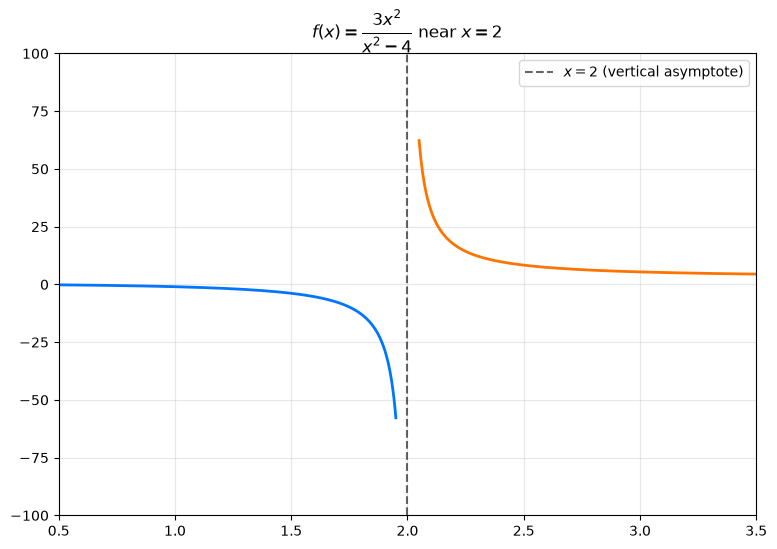

In [5]:
x_vals_right = np.linspace(2.05, 3.5, 400)
x_vals_left = np.linspace(0.5, 1.95, 400)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x_vals_left, (3*x_vals_left**2)/(x_vals_left**2 - 4), color="#0075ff", lw=2)
ax.plot(x_vals_right, (3*x_vals_right**2)/(x_vals_right**2 - 4), color="#ff7300", lw=2)
ax.axvline(2, linestyle="--", color="black", alpha=0.6,
           label=r"$x = 2$ (vertical asymptote)")

ax.set_xlim(0.5, 3.5)
ax.set_ylim(-100, 100)
ax.grid(True, alpha=0.3)
ax.set_title(r"$f(x) = \dfrac{3x^2}{x^2-4}$ near $x = 2$")
ax.legend()
plt.show()

<a id="7"></a>
## 7. Exact Limits with SymPy

Numerics build intuition; SymPy settles the question exactly. First, where can this function break?

In [6]:
import sympy
from sympy import symbols
from sympy.solvers import solve

x = symbols('x')

# Put the equation here
eq = x**2 - 4

# solve() sets the equation equal to zero
print("x = ", solve(eq, x))

x =  [-2, 2]


In [7]:
x = symbols('x')

# Put the equation here
eq = (3*x**2)/(x**2 - 4)

# critical values
critical_points = [-2, 2]

for point in critical_points:
    right = sympy.limit(eq, x, point, dir='+')
    left = sympy.limit(eq, x, point, dir='-')
    print("at x =", point)
    print("right = ", right)
    print("left = ", left)

# infinity
print("as x approaches infinity: ", sympy.limit(eq, x, sympy.oo))
print("as x approaches negative infinity: ", sympy.limit(eq, x, -sympy.oo))

at x = -2
right =  -oo
left =  oo
at x = 2
right =  oo
left =  -oo
as x approaches infinity:  3
as x approaches negative infinity:  3


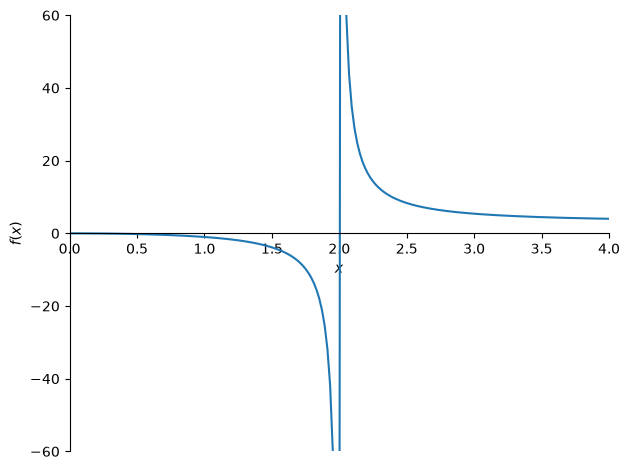

In [8]:
sympy.plot(eq, xlim=(0, 4), ylim=(-60, 60))

<a id="8"></a>
## 8. References

Stewart, J., Clegg, D., & Watson, S. (2021). *Calculus* (9th ed.). Cengage Learning.